In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [11]:
histogram = cv2.imread("../assets/histogram.jpg", 0)


cv2.imshow("Lena", histogram)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [ ]:
# Using the calcHist and LUT is must
def histogram_equalization(image):
    M,N=image.shape
    total_pixels = M*N
    L=256
    # histogram = np.zeros(L, dtype=np.int32)
    # for i in range(M):
    #     for j in range(N):
    #         pixel_intensity=image[i,j]
    #         histogram[pixel_intensity] += 1
    histogram=cv2.calcHist([image], [0], None, [256], [0,256]).flatten()

    probability=np.zeros(L, dtype=np.float32)
    for i in range(L):
        probability[i] = histogram[i]/total_pixels
    
    cumulative_sum_array=np.zeros(L, dtype=np.float32)
    transformation_fn=np.zeros(L, dtype=np.int32)
    for i in range(L):
        cumulative_sum=0.0
        for j in range(i+1):
            cumulative_sum += probability[j]
        cumulative_sum_array[i] = cumulative_sum
        transformation_fn[i] = round((L-1)*cumulative_sum)
        if transformation_fn[i]>255:
            transformation_fn[i]=255

    equalized_image=np.zeros_like(image)
    # for i in range(M):
    #     for j in range(N):
    #         old_value=image[i,j]
    #         new_value=transformation_fn[old_value]
    #         equalized_image[i,j]=new_value
    equalized_image = cv2.LUT(image, transformation_fn.astype(np.uint8))

    return histogram, probability, cumulative_sum_array, transformation_fn, equalized_image


In [13]:
hist, prob, cum_sum_array, trans_fn, equalized = histogram_equalization(histogram)


In [14]:
print("Original Histogram:\n", hist)
print("Probability Distribution:\n", prob)
print("Cumulative Distribution Function:\n", cum_sum_array)
print("Transformation Function:\n", trans_fn)
print("Equalized Image:\n", equalized)

Original Histogram:
 [0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000

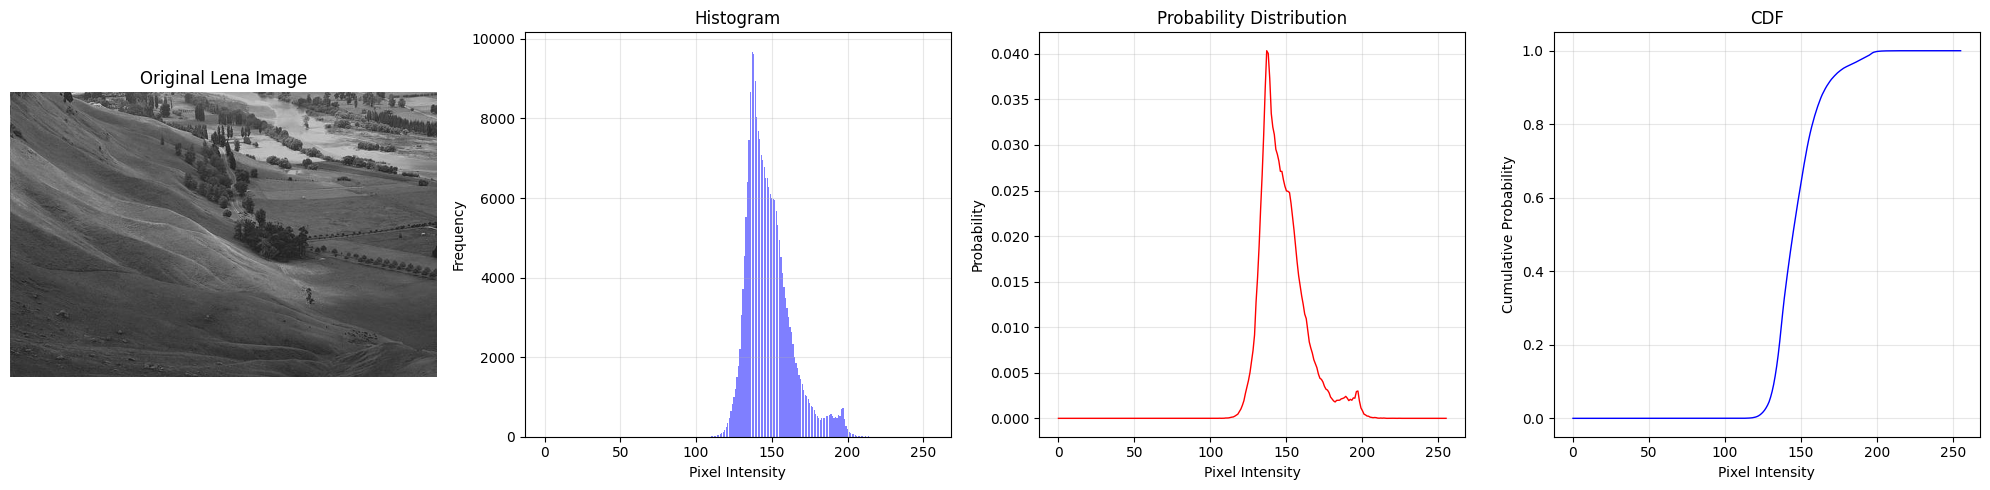

In [15]:
plt.figure(figsize=(20, 5))

# Original Lena image
plt.subplot(1, 4, 1)
plt.imshow(histogram, cmap='gray')
plt.title('Original Lena Image')
plt.axis('off')

# Histogram
plt.subplot(1, 4, 2)
plt.bar(range(256), hist, color='blue', alpha=0.5)
plt.title('Histogram')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

# Probability distribution - outline only
plt.subplot(1, 4, 3)
plt.plot(range(256), prob, color='red', linewidth=1)
plt.title('Probability Distribution')
plt.xlabel('Pixel Intensity')
plt.ylabel('Probability')
plt.grid(True, alpha=0.3)

plt.subplot(1, 4, 4)
plt.plot(range(256), cum_sum_array, color='blue', linewidth=1)
plt.title('CDF')
plt.xlabel('Pixel Intensity')
plt.ylabel('Cumulative Probability')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
hist2, prob2, cum_sum_array2, trans_fn2, equalized2 = histogram_equalization(equalized)


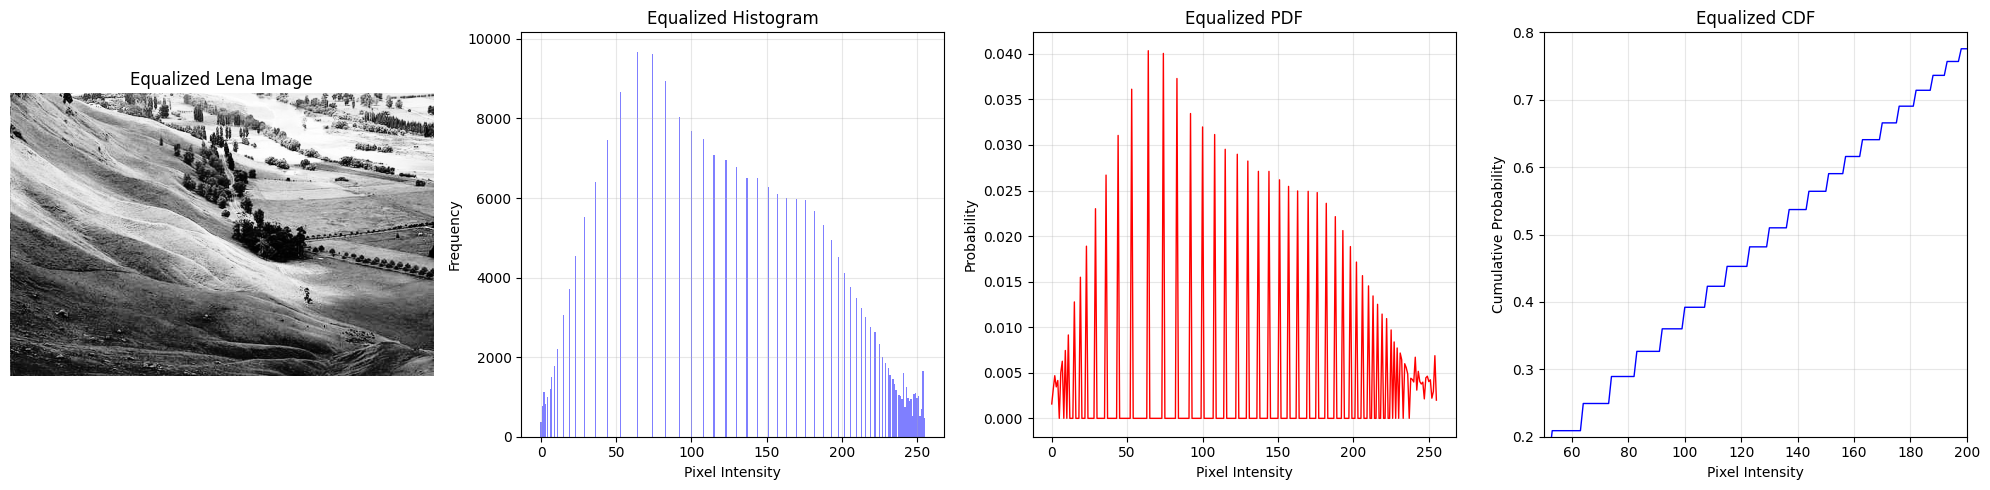

In [17]:
plt.figure(figsize=(20, 5))

# Equalized Lena image
plt.subplot(1, 4, 1)
plt.imshow(equalized2, cmap='gray')
plt.title('Equalized Lena Image')
plt.axis('off')

# Equalized Histogram
plt.subplot(1, 4, 2)
plt.bar(range(256), hist2, color='blue', alpha=0.5)
plt.title('Equalized Histogram')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

# Equalized Probability distribution (PDF) - outline only
plt.subplot(1, 4, 3)
plt.plot(range(256), prob2, color='red', linewidth=1)
plt.title('Equalized PDF')
plt.xlabel('Pixel Intensity')
plt.ylabel('Probability')
plt.grid(True, alpha=0.3)

# Equalized CDF
plt.subplot(1, 4, 4)
plt.plot(range(256), cum_sum_array2, color='blue', linewidth=1)
plt.title('Equalized CDF')
plt.xlabel('Pixel Intensity')
plt.ylabel('Cumulative Probability')
plt.grid(True, alpha=0.3)
plt.xlim(50, 200)  
plt.ylim(0.2, 0.8) 

plt.tight_layout()
plt.show()

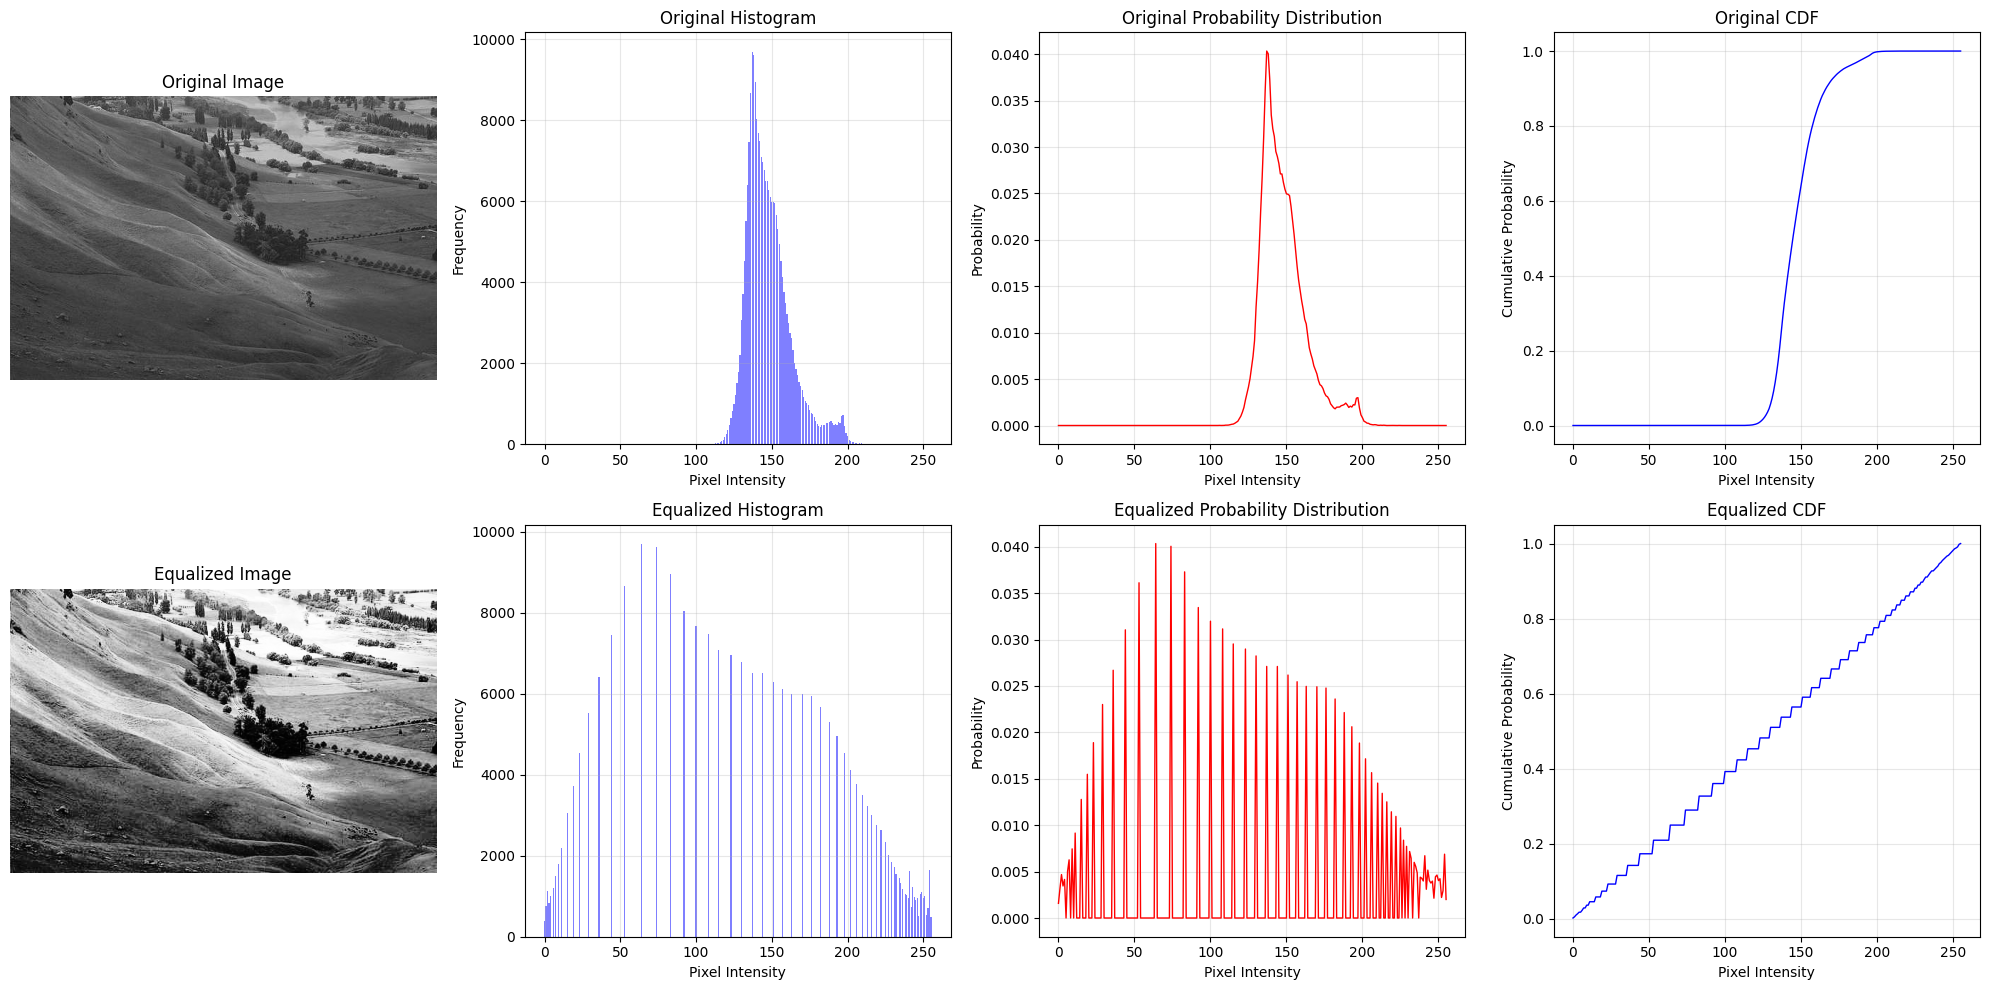

In [18]:
plt.figure(figsize=(20, 10))

# Original Image
plt.subplot(2, 4, 1)
plt.imshow(histogram, cmap='gray')
plt.title('Original Image')
plt.axis('off')

# Original Histogram
plt.subplot(2, 4, 2)
plt.bar(range(256), hist, color='blue', alpha=0.5)
plt.title('Original Histogram')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

# Original Probability Distribution
plt.subplot(2, 4, 3)
plt.plot(range(256), prob, color='red', linewidth=1)
plt.title('Original Probability Distribution')
plt.xlabel('Pixel Intensity')
plt.ylabel('Probability')
plt.grid(True, alpha=0.3)

# Original CDF
plt.subplot(2, 4, 4)
plt.plot(range(256), cum_sum_array, color='blue', linewidth=1)
plt.title('Original CDF')
plt.xlabel('Pixel Intensity')
plt.ylabel('Cumulative Probability')
plt.grid(True, alpha=0.3)

# Equalized Image
plt.subplot(2, 4, 5)
plt.imshow(equalized, cmap='gray')
plt.title('Equalized Image')
plt.axis('off')

# Equalized Histogram
plt.subplot(2, 4, 6)
plt.bar(range(256), hist2, color='blue', alpha=0.5)
plt.title('Equalized Histogram')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

# Equalized Probability Distribution
plt.subplot(2, 4, 7)
plt.plot(range(256), prob2, color='red', linewidth=1)
plt.title('Equalized Probability Distribution')
plt.xlabel('Pixel Intensity')
plt.ylabel('Probability')
plt.grid(True, alpha=0.3)

# Equalized CDF
plt.subplot(2, 4, 8)
plt.plot(range(256), cum_sum_array2, color='blue', linewidth=1)
plt.title('Equalized CDF')
plt.xlabel('Pixel Intensity')
plt.ylabel('Cumulative Probability')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
cv2_hist_eq = cv2.equalizeHist(histogram)

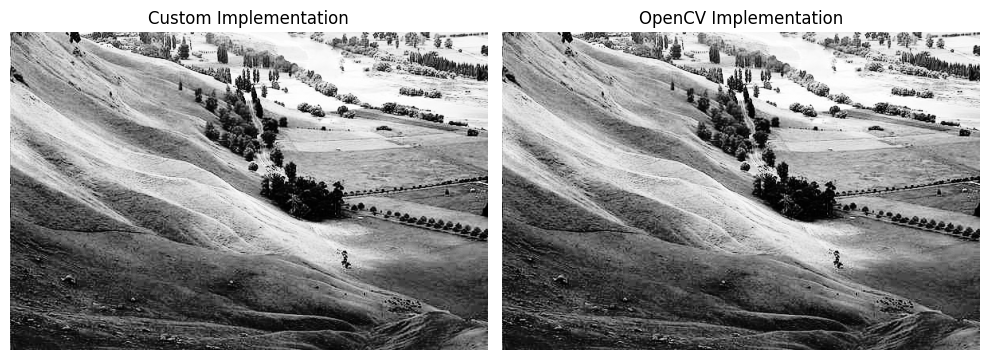

In [22]:
plt.figure(figsize=(10, 5))

# Equalized Image (Your Implementation)
plt.subplot(1, 2, 1)
plt.imshow(equalized, cmap='gray')
plt.title('Custom Implementation')
plt.axis('off')

# Equalized Image (OpenCV Implementation)
plt.subplot(1, 2, 2)
plt.imshow(cv2_hist_eq, cmap='gray')
plt.title('OpenCV Implementation')
plt.axis('off')

plt.tight_layout()
plt.show()